In [1]:
# Ejecutar después de activar el entorno y seleccionar el kernel adecuado:
#!pip install chardet
#!pip install pandas

# Importar:
import chardet # Reconoce caracteres especiales en archivos csv: útil si el archivo está en otro idioma
import geopandas as gpd # Trabaja con datos geoespaciales
import folium as fol # Crea mapas interactivos
import pandas as pd # Trabaja con datos tabulares; csv por ejemplo (Necesario porque es un entorno nuevo)
import matplotlib.pyplot as plt # Crea gráficos
import numpy as np # Para el balanceo de data (Merge), es necesario dataframe vacío (NaN) y 0, y Numpy lo permite

# GEOPANDAS

- <a href='#1.'>I. ¿Qué es Geopandas?</a>
     - <a href='#1.1.'>1.1. Instalación</a>
     - <a href='#1.2.'>1.2. Tipos de datos en Geopandas</a> 
     - <a href='#1.3.'>1.3. Llamando librerías</a> 
- <a href='#2.'>II. Data de COVID (métricas) </a>
     - <a href='#2.1.'>2.1. Importando datos</a>
     - <a href='#2.1.'>2.2. Tratando los datos</a>
- <a href='#3.'>III. Archivos de forma</a>
     - <a href='#3.1.'>3.1. Shape files</a>
     - <a href='#3.2.'>3.2. Tratando los datos</a>
- <a href='#4.'>IV. Merge: Datos de COVID & Shapefile</a>  
     - <a href='#4.1.'>4.1. Balanceo y tratamiento de datos</a>
     - <a href='#4.2.'>4.2. Función por país, provincia o distrito</a>
     - <a href='#4.3.'>4.3. Graficando los casos a nivel distrital</a>  
- <a href='#5.'>V. CENTROIDES</a>    
     - <a href='#5.1.'>5.1. Nombres en el centroides</a>

# <a id ='1.'>I. ¿Qué es Geopandas?</a>

* Geopandas permite el uso y la manipulación de datos geoespaciales en Python. Extiende el tipo de datos común de Pandas para permitir numerosas y únicas operaciones geométricas: GeoSeries y GeoDataFrame. Geopandas también se basa en Shapely para su operación geométrica, dado que su tipo de datos subyacente permite que Geopandas se ejecute a una velocidad increíble y es adecuado para numerosas secuencias de aprendizaje automático que requieren grandes conjuntos de datos geoespaciales.

* Cuando trabajemos con un shape file, tenemos que generar una reproyección. Siempre en **WGS-84**, que es el Sistema de Posicionamiento Global mundial de referencia. Está compuesto por un elipsoide de referencia, un sistema de coordenadas estándar, datos de altitud y un geoide.

* En algunos casos, debido a las distorciones bidimensionales de un plano, una reproyección es requerida. Se usa el Universal Transverse Mercator (UTM) 

## <a id ='1.1.'>1.1. Instalación</a>

* Verficamos de estar en la carpeta del proyecto.
* Crea el entorno geopandas en la Terminal de VS Code: `conda create -n geopandas -c conda-forge geopandas`. Esto porque geopandas tiene varias dependencias que se instalan mejor desde `conda-forge`.
* Luego de crearlo, actívalo con `conda activate geopandas`.
* Verificamos de estar en el entorno geopandas en el Terminal.
* Seleccionar el kernel geopandas.

## <a id ='1.2.'>1.2. Tipos de datos en Geopandas</a>

* **Shapefile (.shp)**: Datos vectoriales que almacenan información geoespacial como topología, geometría de forma, coordenadas, etc. No olvidar que el archivo Shapefile se necesita de archivos .xml, .shk, .sbn, etc.

* **GeoJSON (.geojson)**: Información geoespacial y características relevantes (objeto o cadena) en formato diccionario. Es el más común últimamente por su fácil lectura.

## <a id ='1.3.'>1.3. Llamando librerías</a>

In [2]:
from geopandas import GeoSeries # Importa solo la clase GeoSeries de geopandas
from shapely.geometry import Point, LineString

from folium import Marker, GeoJson
from folium.plugins import MarkerCluster, HeatMap

In [3]:
# Obtener la codificación de caracteres de un archivo csv (previo a su importación):
base = open(r'data/Datos_panel_distritos.csv', 'rb').read() # El archivo de recojo de información puro y duro
det = chardet.detect(base)
charenc = det['encoding']
charenc

'utf-8'

# <a id ='2.'>II. Data de COVID (métricas)</a>

## <a id ='2.1.'>2.1. Importando datos</a>

In [4]:
# Importar archivo CSV:
# Datos del panel desde marzo de 2020 hasta las dos primeras semanas de enero de 2022
cv_data = pd.read_csv(r'data/Datos_panel_distritos.csv', encoding = charenc) # Modo corto
cv_data.head(5)

,Código,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,3,2020,0,0,16
1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,4,2020,47,0,5
2,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,5,2020,165,3,11
3,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,6,2020,119,2,15
4,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,7,2020,175,2,8


**¿DE QUÉ VAN LOS DATOS?**
* Información de cada mes y distrito del COVID en el Perú: casos y muertes

In [5]:
# Veo los tipos de datos de las variables:
cv_data.dtypes # object = string

Código             int64
Departamento         str
Provincia            str
Distrito             str
Mes                int64
Año                int64
Casos              int64
Muertes Covid      int64
Muertes totales    int64
dtype: object

## <a id ='2.2.'>2.2. Tratando los datos</a>

* Cambiamos el nombre de la variable **Código** por **UBIGEO** para fusionarla más tarde con el shapefile de distritos.
* Merge entre **métrica** (nos dan) y **geometría** (archivos de forma).

In [6]:
cv_data = cv_data.rename({'Código':'UBIGEO'}, axis =1 )
cv_data.head(5)

,UBIGEO,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,3,2020,0,0,16
1,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,4,2020,47,0,5
2,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,5,2020,165,3,11
3,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,6,2020,119,2,15
4,10101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,7,2020,175,2,8


# <a id ='3.'>III. Archivos de forma</a>

* Página general: [https://data.humdata.org/](https://data.humdata.org/)
* Datos para Perú: [Link](https://data.humdata.org/dataset/geoboundaries-admin-boundaries-for-peru)
* Archivos:
    * ADM0: Nivel general del Perú
    * ADM1: Departamentos
    * ADM2: Distritos (nos interesa descargar)

## <a id ='3.1.'>3.1. Shape files</a>

In [7]:
# Importar archivo shape file de distritos del Perú:
maps = gpd.read_file(r'data/shape_files/DISTRITOS.shp')


In [8]:
maps

,IDDPTO,DEPARTAMEN,IDPROV,PROVINCIA,IDDIST,DISTRITO,CAPITAL,CODCCPP,AREA,FUENTE,geometry
0,10,HUANUCO,1009,PUERTO INCA,100902,CODO DEL POZUZO,CODO DEL POZUZO,0001,1,INEI,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,10,HUANUCO,1009,PUERTO INCA,100904,TOURNAVISTA,TOURNAVISTA,0001,1,INEI,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,25,UCAYALI,2503,PADRE ABAD,250305,ALEXANDER VON HUMBOLDT,ALEXANDER VON HUMBOLDT,0001,1,INEI,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,25,UCAYALI,2503,PADRE ABAD,250302,IRAZOLA,SAN ALEJANDRO,0001,1,INEI,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,25,UCAYALI,2503,PADRE ABAD,250304,NESHUYA,MONTE ALEGRE,0001,1,INEI,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...,...,...,...,...,...,...,...,...,...
1868,10,HUANUCO,1006,LEONCIO PRADO,100608,CASTILLO GRANDE,CASTILLO GRANDE,0001,1,INEI,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,10,HUANUCO,1006,LEONCIO PRADO,100609,PUEBLO NUEVO,PUEBLO NUEVO,0001,1,INEI,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,10,HUANUCO,1006,LEONCIO PRADO,100610,SANTO DOMINGO DE ANDA,PACAE,0001,1,INEI,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,21,PUNO,2111,SAN ROMAN,211105,SAN MIGUEL,SAN MIGUEL,0001,1,INEI,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


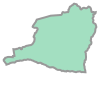

In [9]:
# Gráfico 1: distrito (colección de puntos)
# iloc quiere decir "integer location" (índice)
maps["geometry"].iloc[1872]

In [10]:
# Confirmamos los límites del distrito: 
# Sácame los bordes y solo dame las coordenadas (latitud, longitud) de los puntos que forman el polígono del distrito
maps.geometry[1872].boundary.coords.xy

(array('d', [-77.37630123699995, -77.37604411199999, -77.37473998699988, -77.37356623699998, -77.37215023699997, -77.3706952369999, -77.36967261199993, -77.36794211099993, -77.36601486099988, -77.36385173699989, -77.36164923599989, -77.36015473699996, -77.35838498699991, -77.35712636099998, -77.3561037369999, -77.35445186099992, -77.35331136199994, -77.35248536199992, -77.35247111099989, -77.35150211199993, -77.35071561199993, -77.34992898699988, -77.34831648699998, -77.34662511099998, -77.34560261099995, -77.34458011099997, -77.34405761199992, -77.34367548699998, -77.34273161199997, -77.3420629869999, -77.34143373599989, -77.34115698599999, -77.34092236199996, -77.34080436199997, -77.34005711199995, -77.33848398599997, -77.33756798699994, -77.33663548699997, -77.33447223699994, -77.33309573599985, -77.33128661199999, -77.3299793619999, -77.32967398699998, -77.32786486199996, -77.32631636099995, -77.32664448599996, -77.32740823599988, -77.32899286199984, -77.33084911199995, -77.3323712

* Interpretación: Lo de arriba es x, abajo es y
* Ahora tenemos los datos en sí ` cv_data`  y la forma ` maps`. 
* Verificamos si en `maps` hay valores únicos de distrito.

## <a id ='3.2.'>3.2. Tratando los datos</a>

In [11]:
# Revisamos valores únicos en la variable IDDIST (código de distrito)
# True: cada distrito tiene un código único
maps['IDDIST'].is_unique 

True

In [12]:
#Número de distritos:
maps['IDDIST'].unique().size

1873

In [13]:
# Seleccionamos solo las columnas de interés y renombramos la variable IDDIST a UBIGEO
maps = maps[['IDDIST', 'geometry']] # Selección
maps = maps.rename({'IDDIST':'UBIGEO'}, axis =1 ) # Renombre (en la data de COVID así es la columna de identificación)
maps

,UBIGEO,geometry
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,100904,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,250305,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,250302,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,250304,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...
1868,100608,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,100609,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,100610,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,211105,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


In [14]:
# Convertimos la variable UBIGEO de string a int para hacer el merge con el DataFrame general
# En caso esté en objeto
maps['UBIGEO'] = maps['UBIGEO'].astype(str).astype(int)
maps

,UBIGEO,geometry
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975..."
1,100904,"POLYGON ((-74.64136 -8.82302, -74.64036 -8.828..."
2,250305,"POLYGON ((-75.02253 -8.74193, -75.02267 -8.742..."
3,250302,"POLYGON ((-75.13864 -8.56712, -75.13956 -8.569..."
4,250304,"POLYGON ((-75.01589 -8.44637, -75.01585 -8.446..."
...,...,...
1868,100608,"POLYGON ((-76.08083 -9.13017, -76.08026 -9.130..."
1869,100609,"POLYGON ((-75.88828 -9.00906, -75.88756 -9.010..."
1870,100610,"POLYGON ((-75.91141 -8.88593, -75.91182 -8.886..."
1871,211105,"POLYGON ((-70.13203 -15.33382, -70.12355 -15.3..."


In [15]:
# Sitema WGS-84: Es el sistema de coordenadas geográficas más utilizado en el mundo.
maps.crs 

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

**CONSEJO:**
* Plotear un gráfico pequeño a modo de demostración.

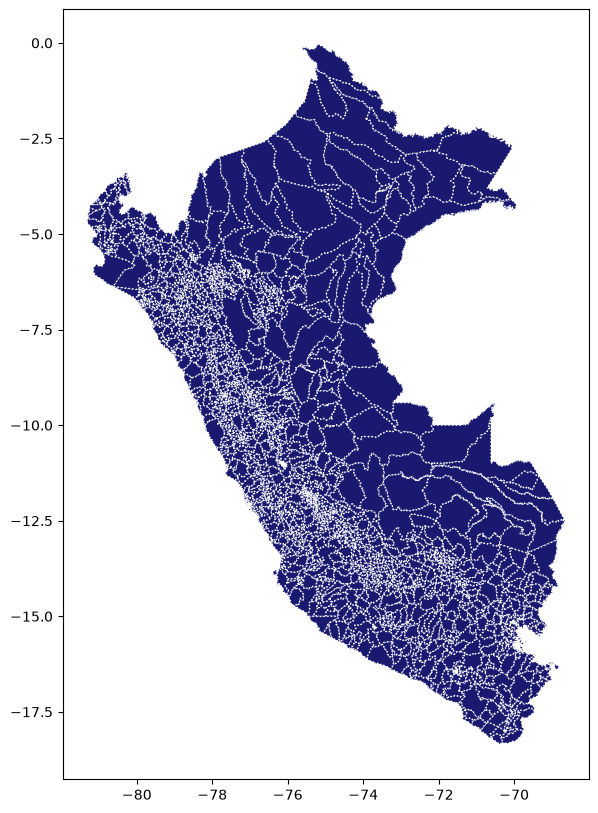

In [16]:
# Gráfico usando geopandas
# Figuras y ejes
fig, ax = plt.subplots(figsize=(10, 10))

maps.plot(  ax=ax, color='midnightblue', linestyle='dotted', # Cualquier color
            edgecolor='white' )
plt.show()

# <a id ='4.'>IV. Merge: Datos de COVID & Shapefile</a>

In [17]:
# Fusionar (merge) usando el método inner para eliminar valores faltantes:
# Nueva base de datos llamada dataset_cv
dataset_cv = pd.merge(maps, cv_data, how="inner", on="UBIGEO") # UBIGEO es la variable común de maps y cv_data
dataset_cv

,UBIGEO,geometry,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
0,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,3,2020,0,0,3
1,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,4,2020,0,1,2
2,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,5,2020,1,0,2
3,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,6,2020,7,0,1
4,100902,"POLYGON ((-75.31797 -9.29529, -75.3171 -9.2975...",HUANUCO,PUERTO INCA,CODO DEL POZUZO,7,2020,11,1,4
...,...,...,...,...,...,...,...,...,...,...
40360,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,9,2021,9,0,20
40361,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,10,2021,11,2,16
40362,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,11,2021,28,1,10
40363,150806,"POLYGON ((-77.3763 -10.89734, -77.37604 -10.89...",LIMA,HUAURA,HUAURA,12,2021,75,1,16


## <a id ='4.1.'>4.1. Balanceo y tratamiento de datos</a>

In [18]:
# Data balanceado: Crear un panel balanceado con todas las combinaciones de UBIGEO, Año y Mes. Si no hay datos, rellenar con NaN o 0.
#Paso 1: Obtener todos los UBIGEOs únicos
ubigeos = dataset_cv['UBIGEO'].unique()

#Paso 2: Crear todas las combinaciones de UBIGEO, Año, Mes
years = dataset_cv['Año'].unique()
months = np.arange(1, 13) # 1 al 12

full_index = pd.MultiIndex.from_product(
    [ubigeos, years, months],
    names=["UBIGEO", "Año", "Mes"]
)

#Paso 3: Establecer el índice en los datos originales para fusionar
dataset_cv_balanced = dataset_cv.set_index(["UBIGEO", "Año", "Mes"])

#Paso 4: Reindexar para crear un panel balanceado
dataset_cv_balanced = dataset_cv_balanced.reindex(full_index).reset_index()

#Paso 5: Rellenar columnas numéricas faltantes con 0 o NaN
numeric_cols = ["Casos", "Muertes Covid", "Muertes totales"]
dataset_cv_balanced[numeric_cols] = dataset_cv_balanced[numeric_cols].fillna("nan")

# Opcional: Rellenar hacia adelante Departamento, Provincia, Distrito, etc.
location_cols = ["Departamento", "Provincia", "Distrito", "geometry"]
dataset_cv_balanced = dataset_cv_balanced.sort_values(["UBIGEO", "Año", "Mes"])
dataset_cv_balanced[location_cols] = dataset_cv_balanced.groupby("UBIGEO")[location_cols].ffill()

dataset_cv_balanced

,UBIGEO,Año,Mes,geometry,Departamento,Provincia,Distrito,Casos,Muertes Covid,Muertes totales
19188,10101,2020,1,None,NaN,NaN,NaN,nan,nan,nan
19189,10101,2020,2,None,NaN,NaN,NaN,nan,nan,nan
19190,10101,2020,3,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,0.0,0.0,16.0
19191,10101,2020,4,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,47.0,0.0,5.0
19192,10101,2020,5,"POLYGON ((-77.88323 -6.17846, -77.88071 -6.179...",AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,165.0,3.0,11.0
...,...,...,...,...,...,...,...,...,...,...
48307,250401,2022,8,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,nan,nan,nan
48308,250401,2022,9,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,nan,nan,nan
48309,250401,2022,10,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,nan,nan,nan
48310,250401,2022,11,"POLYGON ((-70.50719 -9.42663, -70.50693 -9.426...",UCAYALI,PURUS,PURUS,nan,nan,nan


In [19]:
dataset_cv_balanced.dtypes

UBIGEO                int64
Año                   int64
Mes                   int64
geometry           geometry
Departamento            str
Provincia               str
Distrito                str
Casos                object
Muertes Covid        object
Muertes totales      object
dtype: object

## <a id ='4.2.'>4.2. Función por país, provincia o distrito</a>

In [20]:
# Función para filtrar el conjunto de dataset_covid por año, mes y provincia
# Para plotear todo el Perú, provincia o distrito
def subdata(a, b, c):
    
    if c == "All-Peru":
        
        resultado = dataset_cv.loc[(dataset_cv['Año']== a) & (dataset_cv['Mes']== b)]
    else:
        resultado = dataset_cv.loc[(dataset_cv['Año']== a) & (dataset_cv['Mes']== b) & (dataset_cv['Provincia']== c)]
    return resultado  


In [21]:
#base.Provincia.unique()

In [22]:
#Ejemplo:
# Segunda ola 
base = subdata(2020 , 8, "All-Peru")  #Todo el Perú Aug-2020

# Segunda ola solo en Lima
base_lima = subdata(2020 , 8, "LIMA")  #Provincia de Lima Aug-2020

#Segunda ola solo en Lucanas, Ayacucho
base_ayacucho = subdata(2020 , 10, "LUCANAS")  #Provincia de Lucanas Aug-2020

In [23]:
base_ayacucho

,UBIGEO,geometry,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales
24617,50618,"POLYGON ((-74.45485 -14.15098, -74.45421 -14.1...",AYACUCHO,LUCANAS,SAN PEDRO DE PALCO,10,2020,0,0,0
37773,50617,"POLYGON ((-74.12341 -14.73414, -74.12249 -14.7...",AYACUCHO,LUCANAS,SAN PEDRO,10,2020,1,0,0
37819,50621,"POLYGON ((-74.39258 -14.72377, -74.39211 -14.7...",AYACUCHO,LUCANAS,SANTA LUCIA,10,2020,0,0,0
37842,50615,"POLYGON ((-74.28449 -14.69725, -74.28211 -14.6...",AYACUCHO,LUCANAS,SAN CRISTOBAL,10,2020,2,0,0
37957,50619,"POLYGON ((-74.04573 -14.91, -74.04615 -14.9127...",AYACUCHO,LUCANAS,SANCOS,10,2020,6,0,0
38003,50614,"POLYGON ((-74.36156 -14.77078, -74.35963 -14.7...",AYACUCHO,LUCANAS,SAISA,10,2020,0,0,0
38026,50605,"POLYGON ((-73.8766 -14.80292, -73.87742 -14.80...",AYACUCHO,LUCANAS,CHAVI<d1>A,10,2020,0,0,2
38049,50616,"POLYGON ((-74.17274 -14.59704, -74.17246 -14.5...",AYACUCHO,LUCANAS,SAN JUAN,10,2020,0,0,0
38417,50609,"POLYGON ((-74.43725 -14.52504, -74.43454 -14.5...",AYACUCHO,LUCANAS,LEONCIO PRADO,10,2020,1,0,0
38440,50606,"POLYGON ((-73.85391 -14.2781, -73.85018 -14.28...",AYACUCHO,LUCANAS,CHIPAO,10,2020,2,0,1


**SINTETIZANDO:**
* BD con datos numéricos del Covid: `dataset_cv_balanced`, pero usaremos `base` para graficar por cuestiones prácticas.
* BD con los mapas: `maps`.

## <a id ='4.3.'>4.3. Graficando los casos a nivel distrital</a>

* Usamos el objeto `base` para graficar porque queremos ver el recojo de muestras, nada más.
* Para modelos econométricos o cuestiones más avanzadas, usamos `dataset_cv_balanced`.

**HISTOGRAMAS:**

* Primero, veamos la distribución de la variable antes de plotear

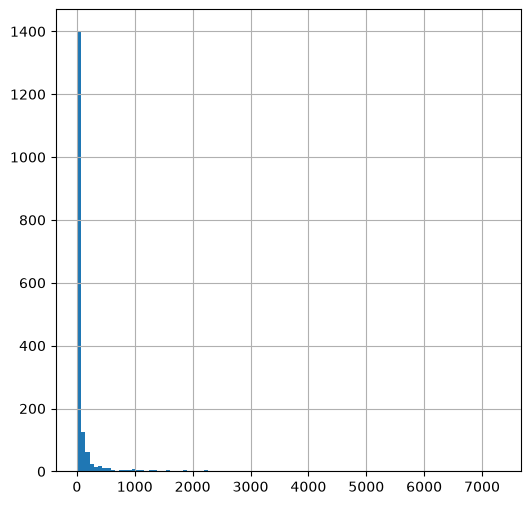

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
base["Casos"].hist(bins=100)
plt.show()

<Axes: >

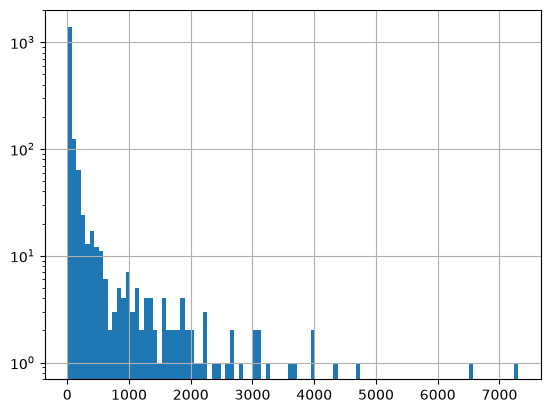

In [25]:
base["Casos"].hist(bins=100, log=True)

**MAPA DEL PERÚ DISTRITAL:**

<Axes: >

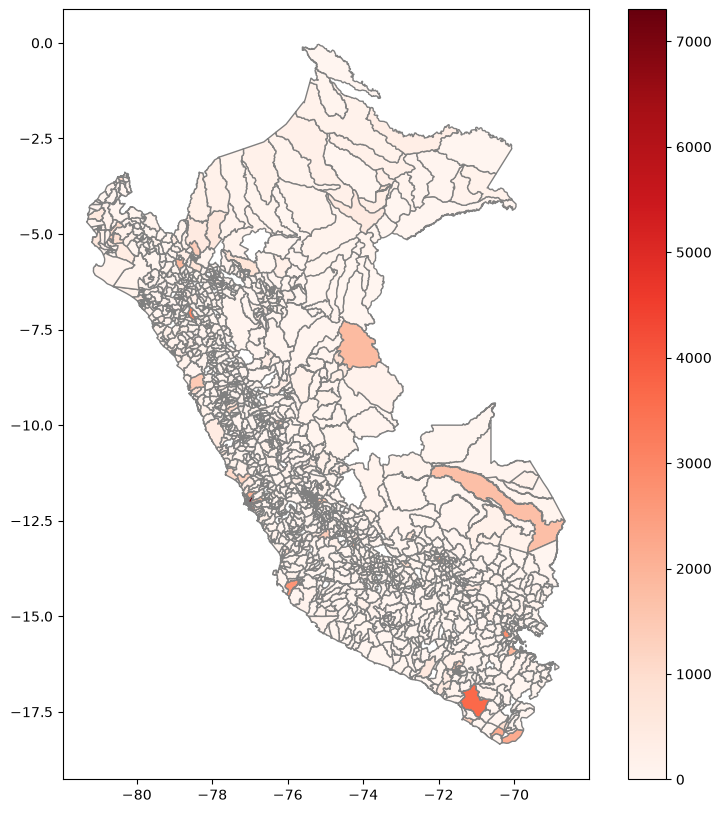

In [26]:
# Ploteando la columna de casos de covid (archivo base)
base.plot(column='Casos', 
          cmap='Reds', 
          figsize=(10, 10),
          linestyle='-',
          edgecolor='gray',
          legend=True)

* Sale así porque hay distritos donde nunca se ha levantado data. Es como si no existieran: son los NaN al momento de hacer Merge.
* Como se hizo inner, obligué a que la data tomara como referencia la base del covid (base)
* Por eso algunos distritos no aparecen en el mapa.

NameError: name 'sm' is not defined

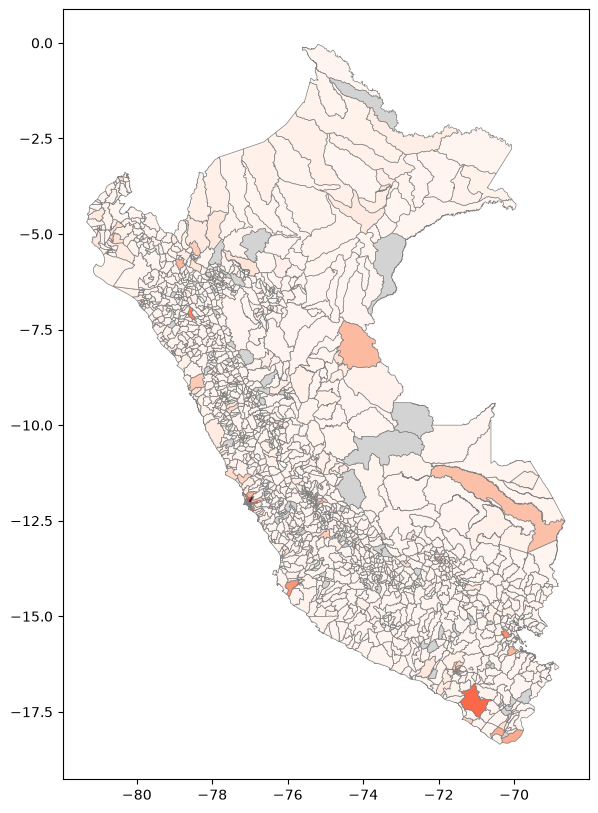

In [27]:
# Arreglando el mapa anterior:

# Merge con todos los distritos (maps) con la data covid (base)
# Asumiendo una llave común: 'UBIGEO'
merged = maps.merge(base[['UBIGEO', 'Casos']], 
                    on='UBIGEO', how='left') # El left mantiene todos los distritos. Es la clave.

fig, ax = plt.subplots(figsize=(10, 10))

# Graficando todos los polígonos
merged.plot(
    column='Casos',
    cmap='Reds',
    linewidth=0.5,
    ax=ax,
    edgecolor='gray',
    missing_kwds={
        "color": "lightgray",  # fill for missing data
        "edgecolor": "gray",
        "label": "No data"
    }
)

sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("COVID-19 Cases", fontsize=12)

**MAPA DE LIMA DISTRITAL:**

In [ ]:
base_lima.columns

Index(['UBIGEO', 'geometry', 'Departamento', 'Provincia', 'Distrito', 'Mes',
       'Año', 'Casos', 'Muertes Covid', 'Muertes totales'],
      dtype='str')

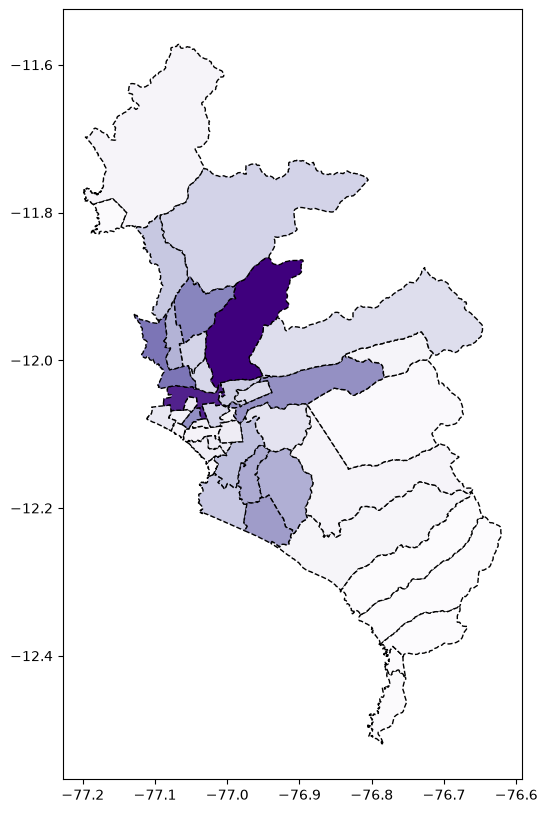

In [ ]:
# Covid en Lima Matropolitana en Casos (puedo cambiarlo a Muertes Covid)

base_lima.plot(column='Casos', cmap='Purples', figsize=(10, 10), linestyle='--',
                      edgecolor='black')

# Guardar el mapa (en la carpeta de imágenes)
plt.savefig('images/Lima_covidcasos_Heatmap.png')

Y así con provincias. Si quiero a nivel de departamento, hago el merge con el shapefile de departamentos.
Bajo el shapefile de provincia y sumo.

## <a id ='5.'>V. CENTROIDES</a>

* Es el centro de un polígono, formado por la intersección de sus líneas rectas.

In [ ]:
# Centroide:
base_lima["geometry"]

8147     POLYGON ((-76.70549 -12.17672, -76.70429 -12.1...
9090     POLYGON ((-77.06517 -11.57512, -77.06505 -11.5...
11689    POLYGON ((-77.04859 -12.08504, -77.04762 -12.0...
11712    POLYGON ((-77.0721 -12.08358, -77.06348 -12.08...
11735    POLYGON ((-76.98732 -12.07994, -76.98425 -12.0...
11758    POLYGON ((-77.02807 -12.07871, -77.02435 -12.0...
11781    POLYGON ((-76.95923 -12.07576, -76.95831 -12.0...
11850    POLYGON ((-77.04966 -12.07025, -77.05097 -12.0...
12379    POLYGON ((-77.14355 -11.79587, -77.14061 -11.7...
15047    POLYGON ((-76.89995 -11.72979, -76.89921 -11.7...
21579    POLYGON ((-77.03811 -12.06768, -77.03629 -12.0...
22131    POLYGON ((-76.77367 -12.42553, -76.77332 -12.4...
22154    MULTIPOLYGON (((-76.78117 -12.40917, -76.78144...
22315    POLYGON ((-77.00745 -12.16033, -77.00781 -12.1...
22384    POLYGON ((-77.01945 -12.1306, -77.01915 -12.13...
22430    POLYGON ((-76.91078 -12.12233, -76.91191 -12.1...
22453    POLYGON ((-76.95434 -12.11556, -76.95416 -12.1.

In [ ]:
# Genero una columna centroide en la base de Lima
# Dicha geometría la proyectamos en metros (EPSG:24891) para calcular el centroide y luego la volvemos a proyectar a WGS84 (EPSG:4326)
base_lima['centroid'] = base_lima['geometry'].to_crs("EPSG:24891").centroid.to_crs("EPSG:4326")

In [ ]:
# Tenemos al punto centroide de cada distrito
base_lima


,UBIGEO,geometry,Departamento,Provincia,Distrito,Mes,Año,Casos,Muertes Covid,Muertes totales,centroid
8147,150119,"POLYGON ((-76.70549 -12.17672, -76.70429 -12.1...",LIMA,LIMA,LURIN,8,2020,452,29,68,POINT (-76.80109 -12.23426)
9090,150102,"POLYGON ((-77.06517 -11.57512, -77.06505 -11.5...",LIMA,LIMA,ANCON,8,2020,460,30,51,POINT (-77.0958 -11.70252)
11689,150131,"POLYGON ((-77.04859 -12.08504, -77.04762 -12.0...",LIMA,LIMA,SAN ISIDRO,8,2020,551,30,86,POINT (-77.03667 -12.09898)
11712,150120,"POLYGON ((-77.0721 -12.08358, -77.06348 -12.08...",LIMA,LIMA,MAGDALENA DEL MAR,8,2020,478,49,94,POINT (-77.06669 -12.09384)
11735,150130,"POLYGON ((-76.98732 -12.07994, -76.98425 -12.0...",LIMA,LIMA,SAN BORJA,8,2020,1012,54,123,POINT (-76.99521 -12.09755)
11758,150116,"POLYGON ((-77.02807 -12.07871, -77.02435 -12.0...",LIMA,LIMA,LINCE,8,2020,855,76,129,POINT (-77.03567 -12.08579)
11781,150140,"POLYGON ((-76.95923 -12.07576, -76.95831 -12.0...",LIMA,LIMA,SANTIAGO DE SURCO,8,2020,2628,171,394,POINT (-76.98431 -12.12699)
11850,150121,"POLYGON ((-77.04966 -12.07025, -77.05097 -12.0...",LIMA,LIMA,PUEBLO LIBRE,8,2020,633,61,140,POINT (-77.06574 -12.07508)
12379,150139,"POLYGON ((-77.14355 -11.79587, -77.14061 -11.7...",LIMA,LIMA,SANTA ROSA,8,2020,114,9,15,POINT (-77.16325 -11.80501)
15047,150106,"POLYGON ((-76.89995 -11.72979, -76.89921 -11.7...",LIMA,LIMA,CARABAYLLO,8,2020,2054,183,281,POINT (-76.97291 -11.80738)


## <a id ='5.1.'>5.1. Nombres en el centroide</a>

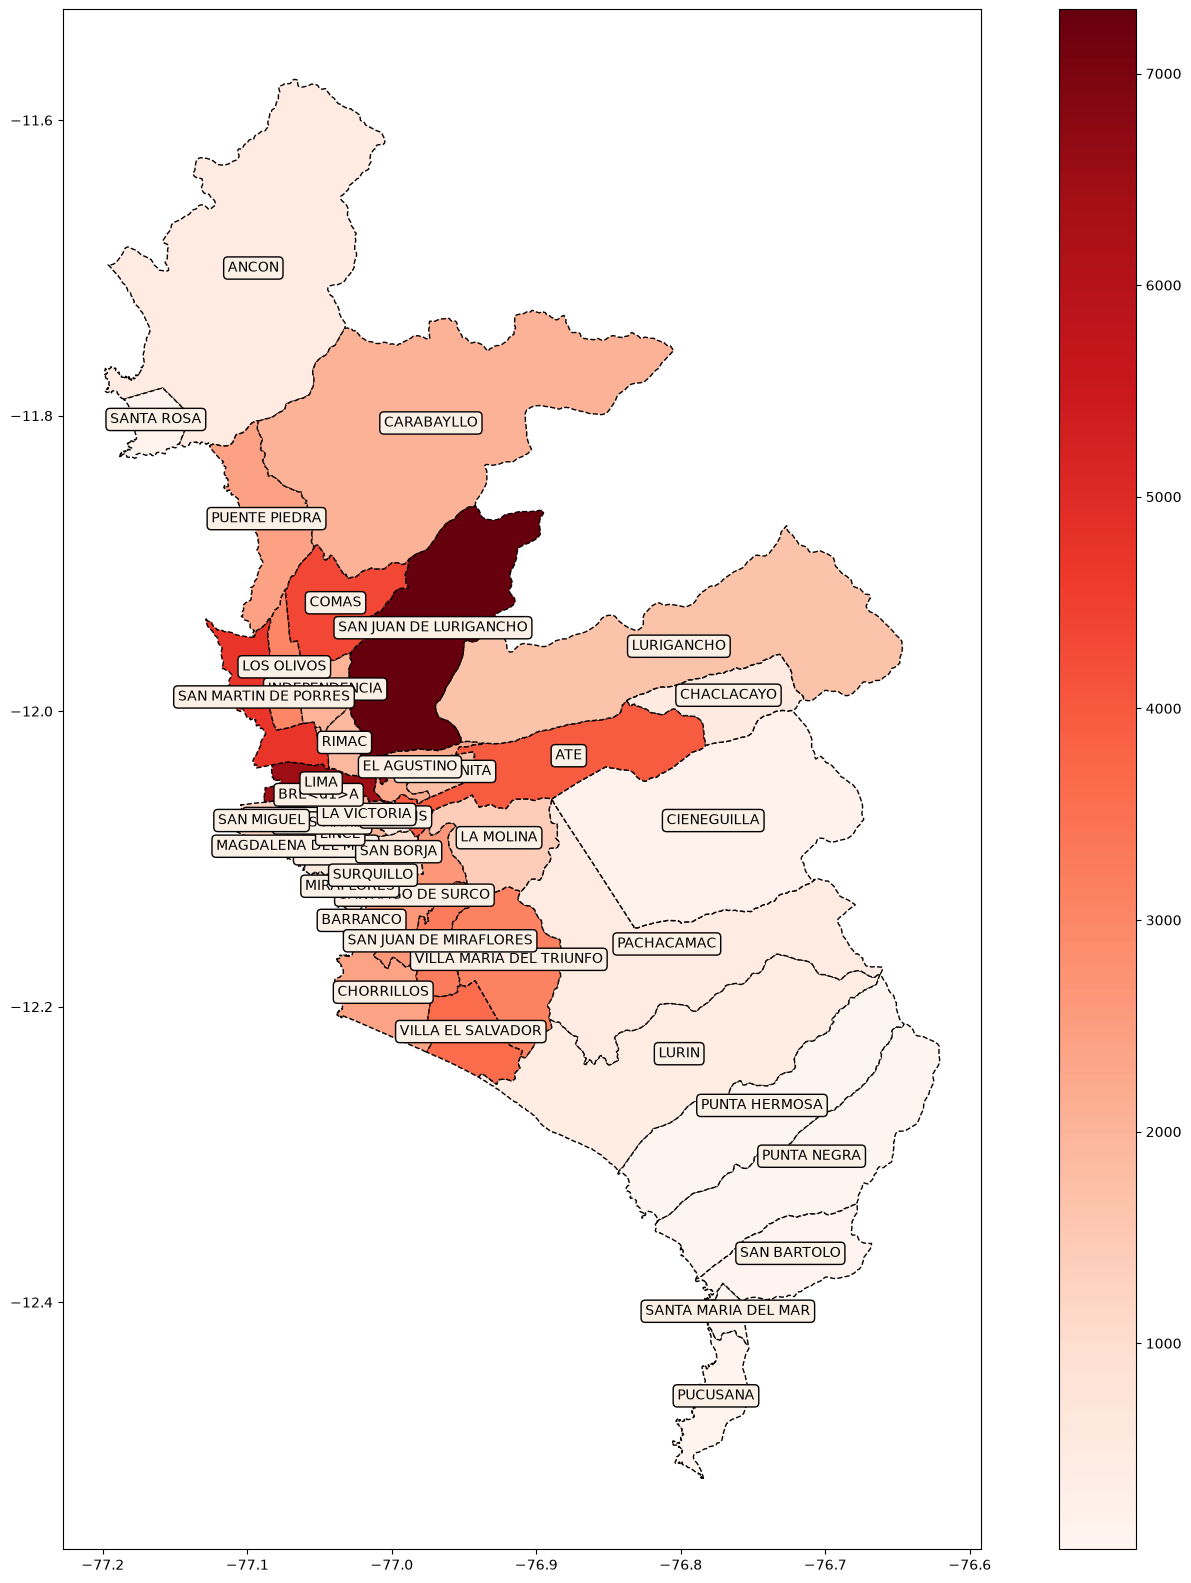

In [ ]:
# Ploteos bonitos:
fig, ax = plt.subplots(figsize=(20, 20))

# Mapa de calor Lima y contagios de Covid:
base_lima.plot(column='Casos', cmap='Reds', linestyle='--',
                      edgecolor='black', 
                      legend = True, ax=ax)

# Añadiendo etiquetas de los distritos en el centroide
props = dict(boxstyle='round', facecolor = 'linen', alpha =1) # Caja redondeada, color de fondo linen, transparencia 1

for point in base_lima.iterrows():
        ax.text( point[1]['centroid'].x,
                 point[1]['centroid'].y,
                 point[1]['Distrito'],
                 horizontalalignment='center', #En el centro
                 fontsize=10,
                 bbox=props )

# Guardar la imagen
#plot.savefig(r'images/Lima_covid_Heatmap_2.png')

**TAREA:**

* Generar plots, radios con Centros Poblados con [Datos abiertos INEI](https://www.datosabiertos.gob.pe/dataset/dataset-centros-poblados)
